# Simulation results analysis — MPM only

Reads `Input_Results_redo.csv`. All plots use the corrected MPM `|MPM - Mean|`.

1. Per Hs pair: MPM vs Tp, 3 DOFs, averaged over directions, one line per damping case.
2. Per Hs pair: MPM vs Tp, 3 DOFs, low damping only, one line per direction.
3. Quadratic vs linear damping: % MPM reduction relative to `low` plotted vs Hs (showing the Hs trend).
4. Same comparison plotted vs Tp.
5. `average` damping vs the per-DOF best of {linhigh, quadhigh}: how far off is the compromise?
6. Worst-case direction vs the mean-over-directions: shows how much information the averaging hides.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TITLE_SIZE = 16
LABEL_SIZE = 14
TICK_SIZE = 12

plt.rcParams.update({
    'axes.titlesize': TITLE_SIZE,
    'axes.labelsize': LABEL_SIZE,
    'xtick.labelsize': TICK_SIZE,
    'ytick.labelsize': TICK_SIZE,
    'legend.fontsize': TICK_SIZE,
    'figure.titlesize': TITLE_SIZE,
})

In [13]:
df = pd.read_csv('Simulation_output_redo.csv')

for col in ['Damp_Heave', 'Damp_Roll', 'Damp_Pitch']:
    df[col] = df[col].replace({'DOFbest': 'average'})

for suffix in ['Z', 'pitch', 'roll']:
    df[f'MPM {suffix} corr'] = (df[f'MPM {suffix}'] - df[f'Mean {suffix}'])

DOFS = [
    {'key': 'Z',     'name': 'Heave', 'unit': 'm'},
    {'key': 'pitch', 'name': 'Pitch', 'unit': 'deg'},
    {'key': 'roll',  'name': 'Roll',  'unit': 'deg'},
]

DAMPING_CASES = ['low', 'linhigh', 'quadhigh', 'average']
DAMPING_COLORS = {
    'low':      '#1f77b4',
    'linhigh':  '#ff7f0e',
    'quadhigh': '#2ca02c',
    'average':  '#d62728',
}

HS_VALUES = sorted(df['Hs'].unique())
DIRECTIONS = sorted(df['Direction'].unique())

def damping_col(dof_key):
    return {'Z': 'Damp_Heave', 'pitch': 'Damp_Pitch', 'roll': 'Damp_Roll'}[dof_key]

def hs_pairs(values):
    """Group Hs values into pairs of 2 for side-by-side plotting."""
    return [values[i:i+2] for i in range(0, len(values), 2)]

print('Hs values:', HS_VALUES)
print('Directions:', DIRECTIONS)

Hs values: [np.int64(1), np.int64(2), np.int64(4), np.int64(6), np.int64(8)]
Directions: [np.int64(0), np.int64(45), np.int64(90), np.int64(135), np.int64(180)]


## 1. MPM vs Tp, averaged over directions — 2 Hs per figure

3 rows (DOFs) × 2 columns (Hs), one line per damping case.

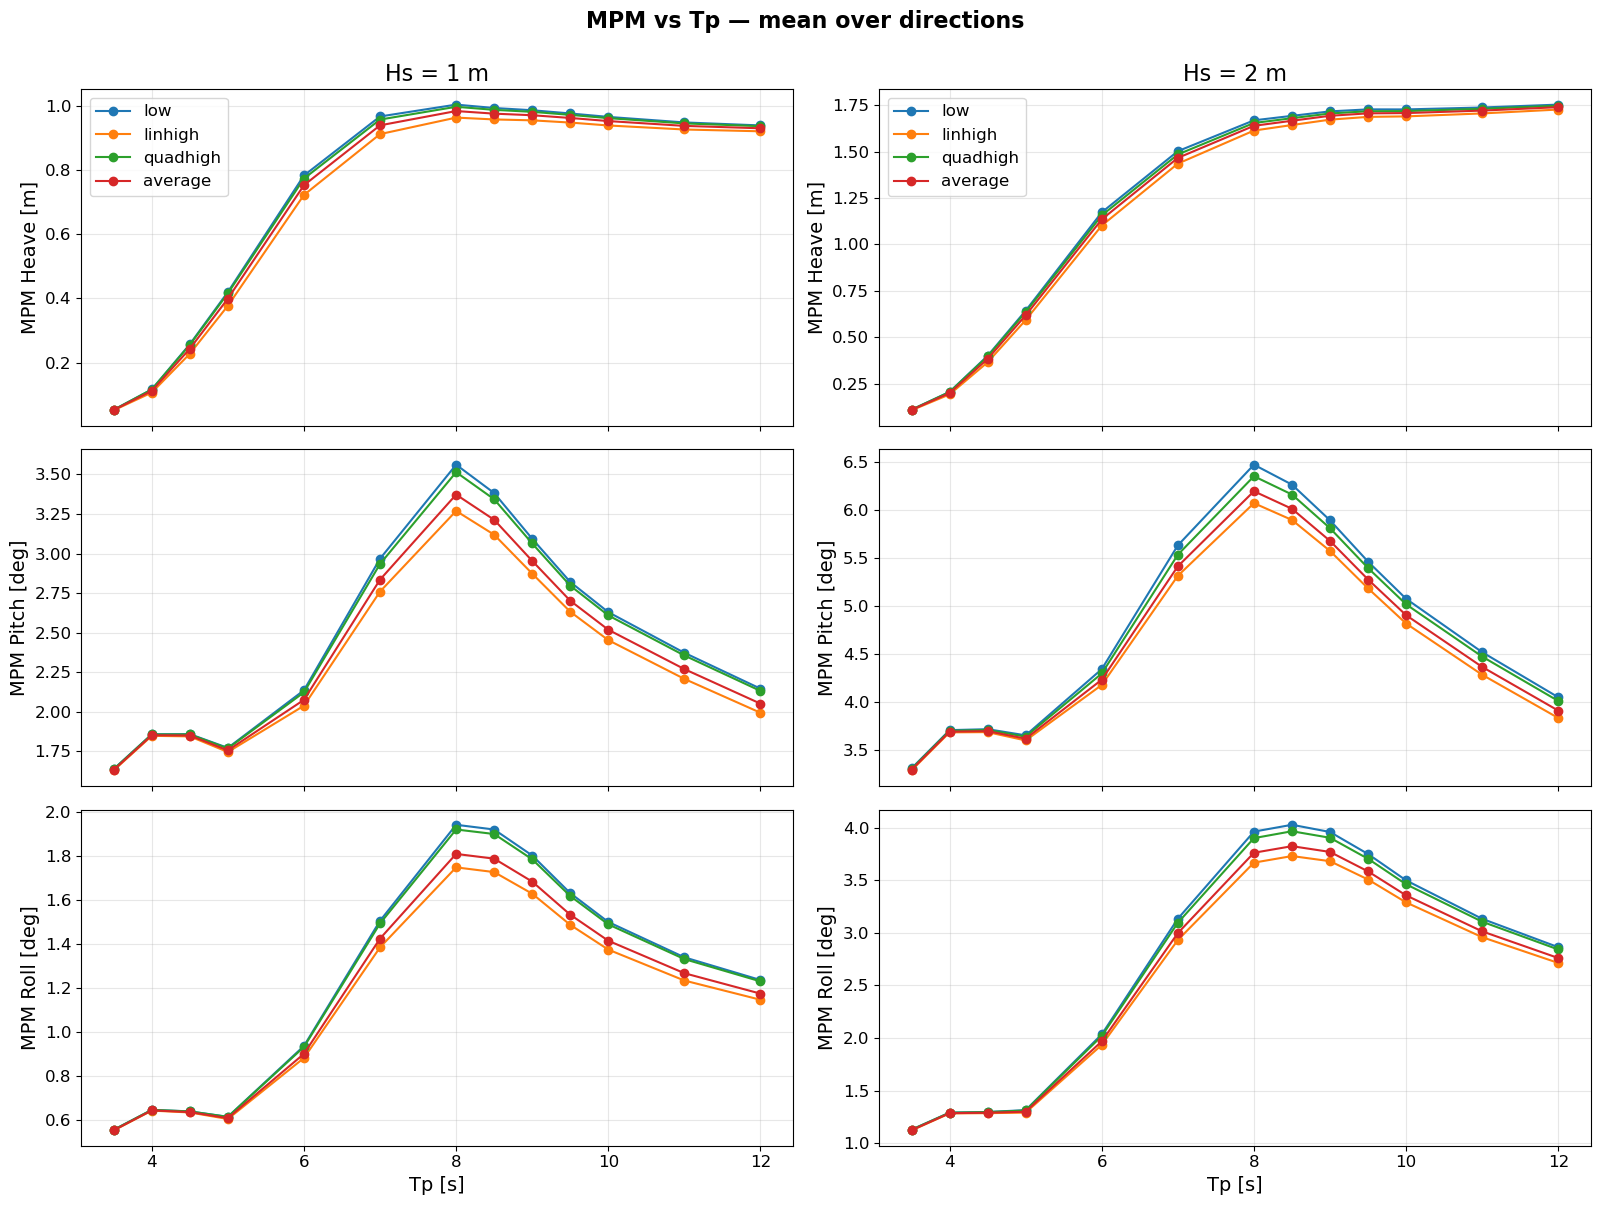

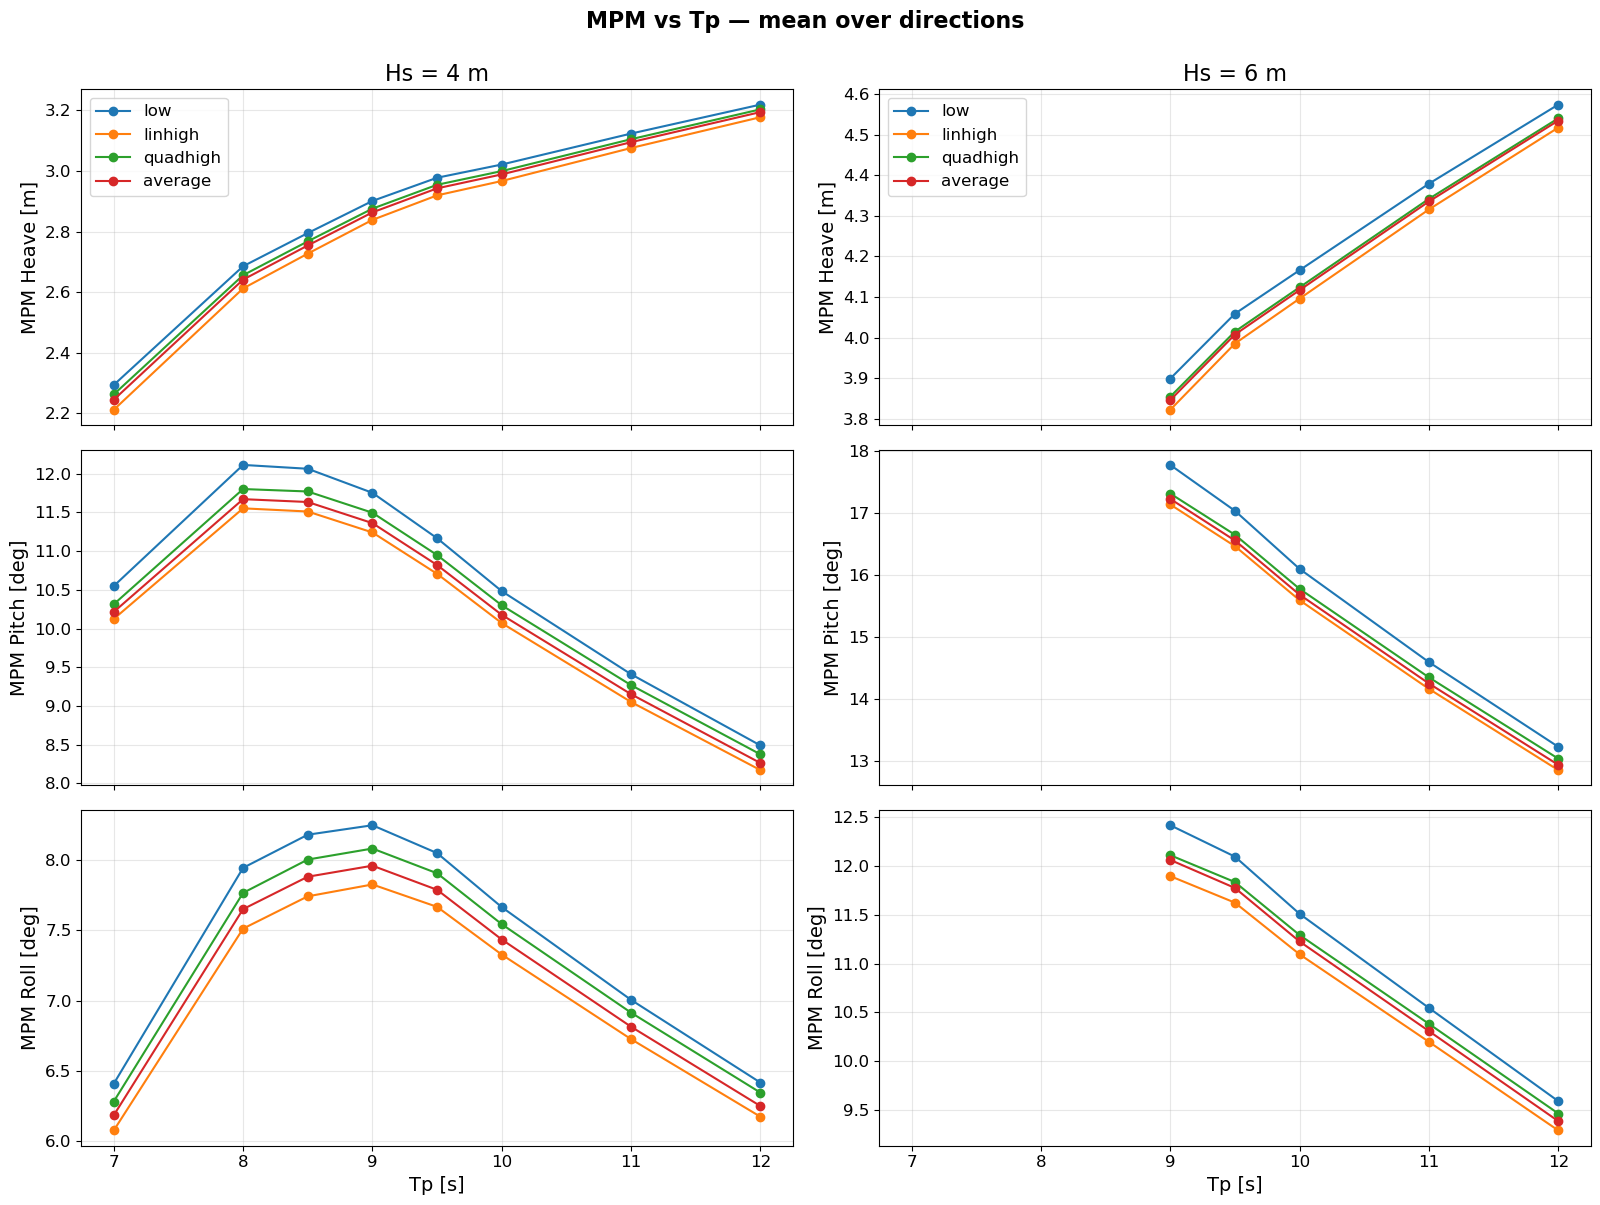

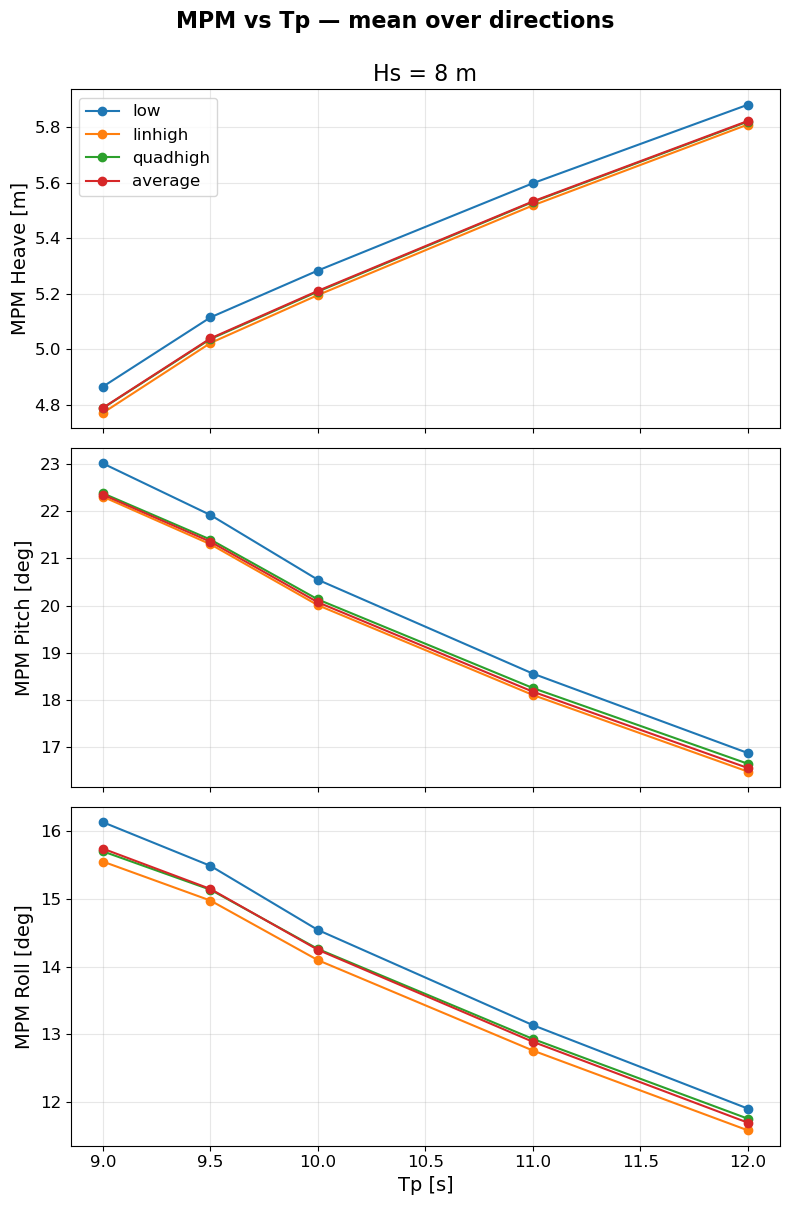

In [14]:
for hs_pair in hs_pairs(HS_VALUES):
    ncols = len(hs_pair)
    fig, axes = plt.subplots(3, ncols, figsize=(8*ncols, 12), sharex=True, squeeze=False)

    for c, hs in enumerate(hs_pair):
        sub_hs = df[df['Hs'] == hs]
        for r, dof in enumerate(DOFS):
            dcol = damping_col(dof['key'])
            mpm_c = f'MPM {dof["key"]} corr'
            ax = axes[r, c]

            for case in DAMPING_CASES:
                sub_case = sub_hs[sub_hs[dcol] == case]
                if sub_case.empty:
                    continue
                grouped = sub_case.groupby('Tp')[mpm_c].mean().sort_index()
                ax.plot(grouped.index, grouped.values, 'o-',
                        label=case, color=DAMPING_COLORS[case])

            ax.set_ylabel(f'MPM {dof["name"]} [{dof["unit"]}]')
            ax.grid(True, alpha=0.3)
            if r == 0:
                ax.set_title(f'Hs = {hs} m')
                ax.legend()
            if r == 2:
                ax.set_xlabel('Tp [s]')

    fig.suptitle('MPM vs Tp — mean over directions', y=1.00, fontweight='bold')
    fig.tight_layout()
plt.show()

## 2. MPM vs Tp per direction (low damping only) — 2 Hs per figure

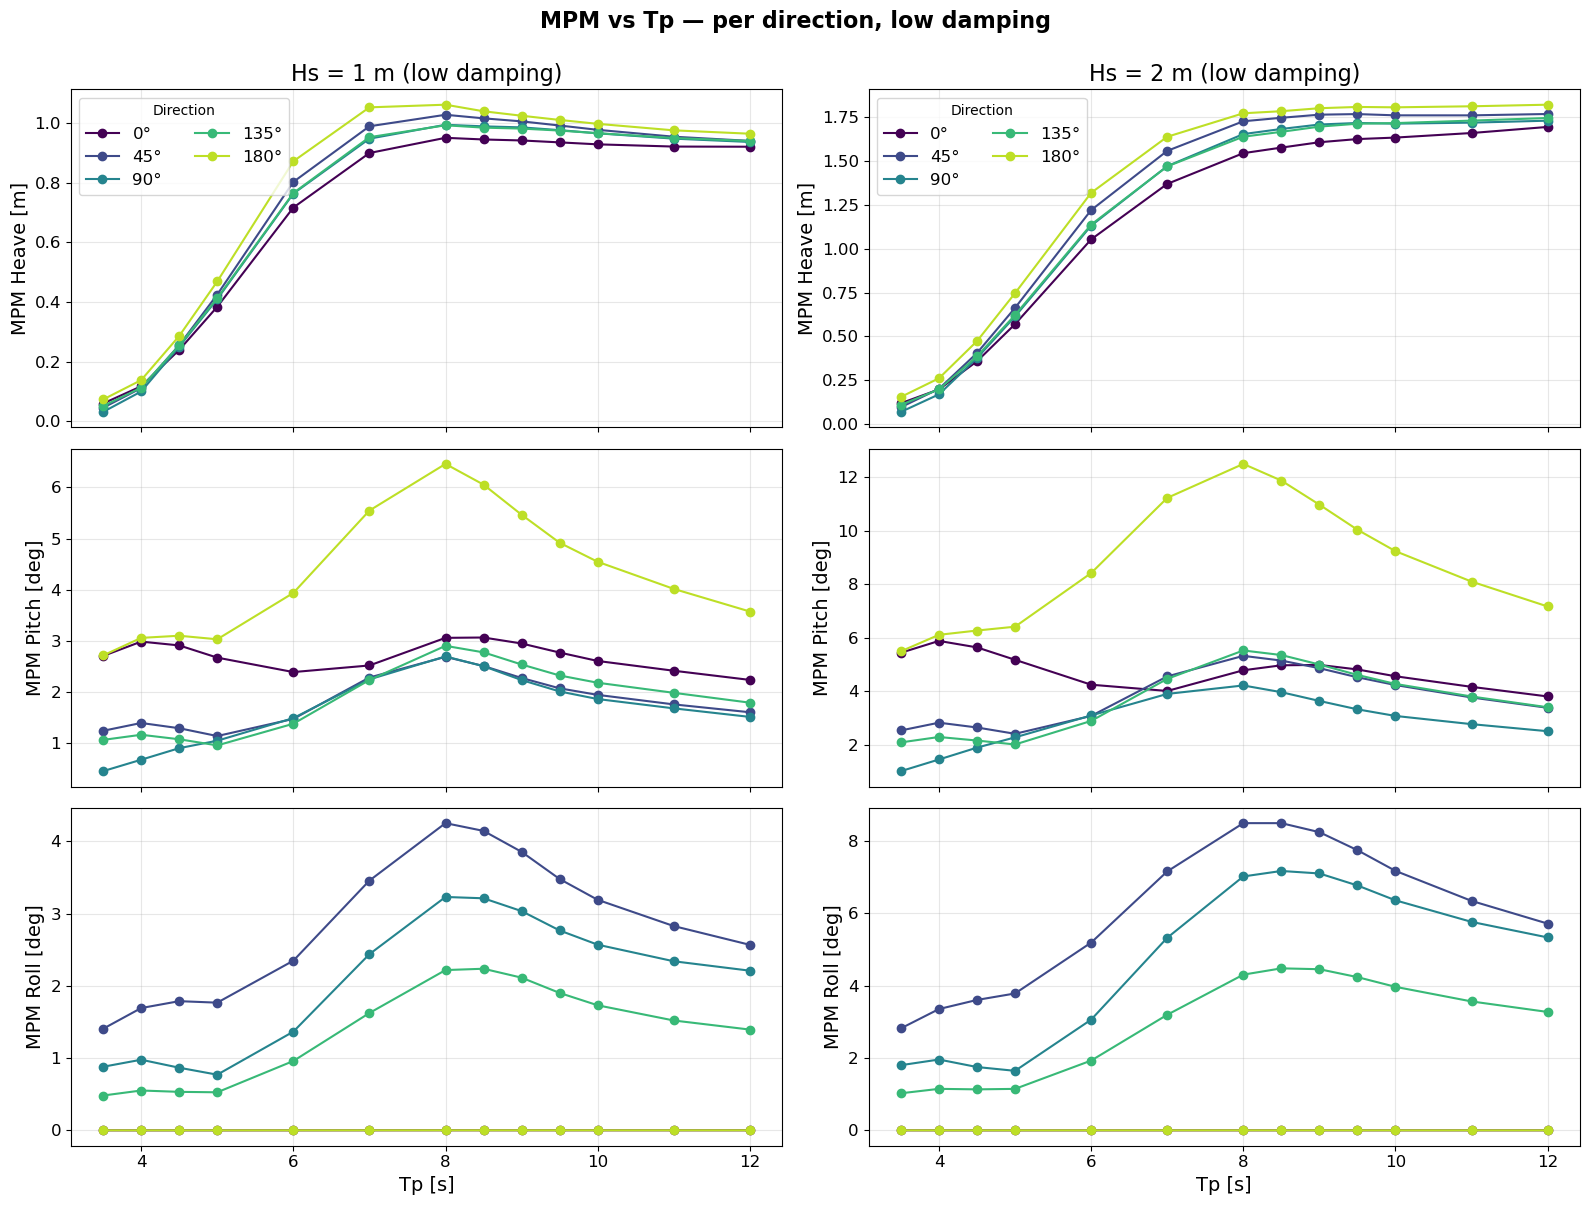

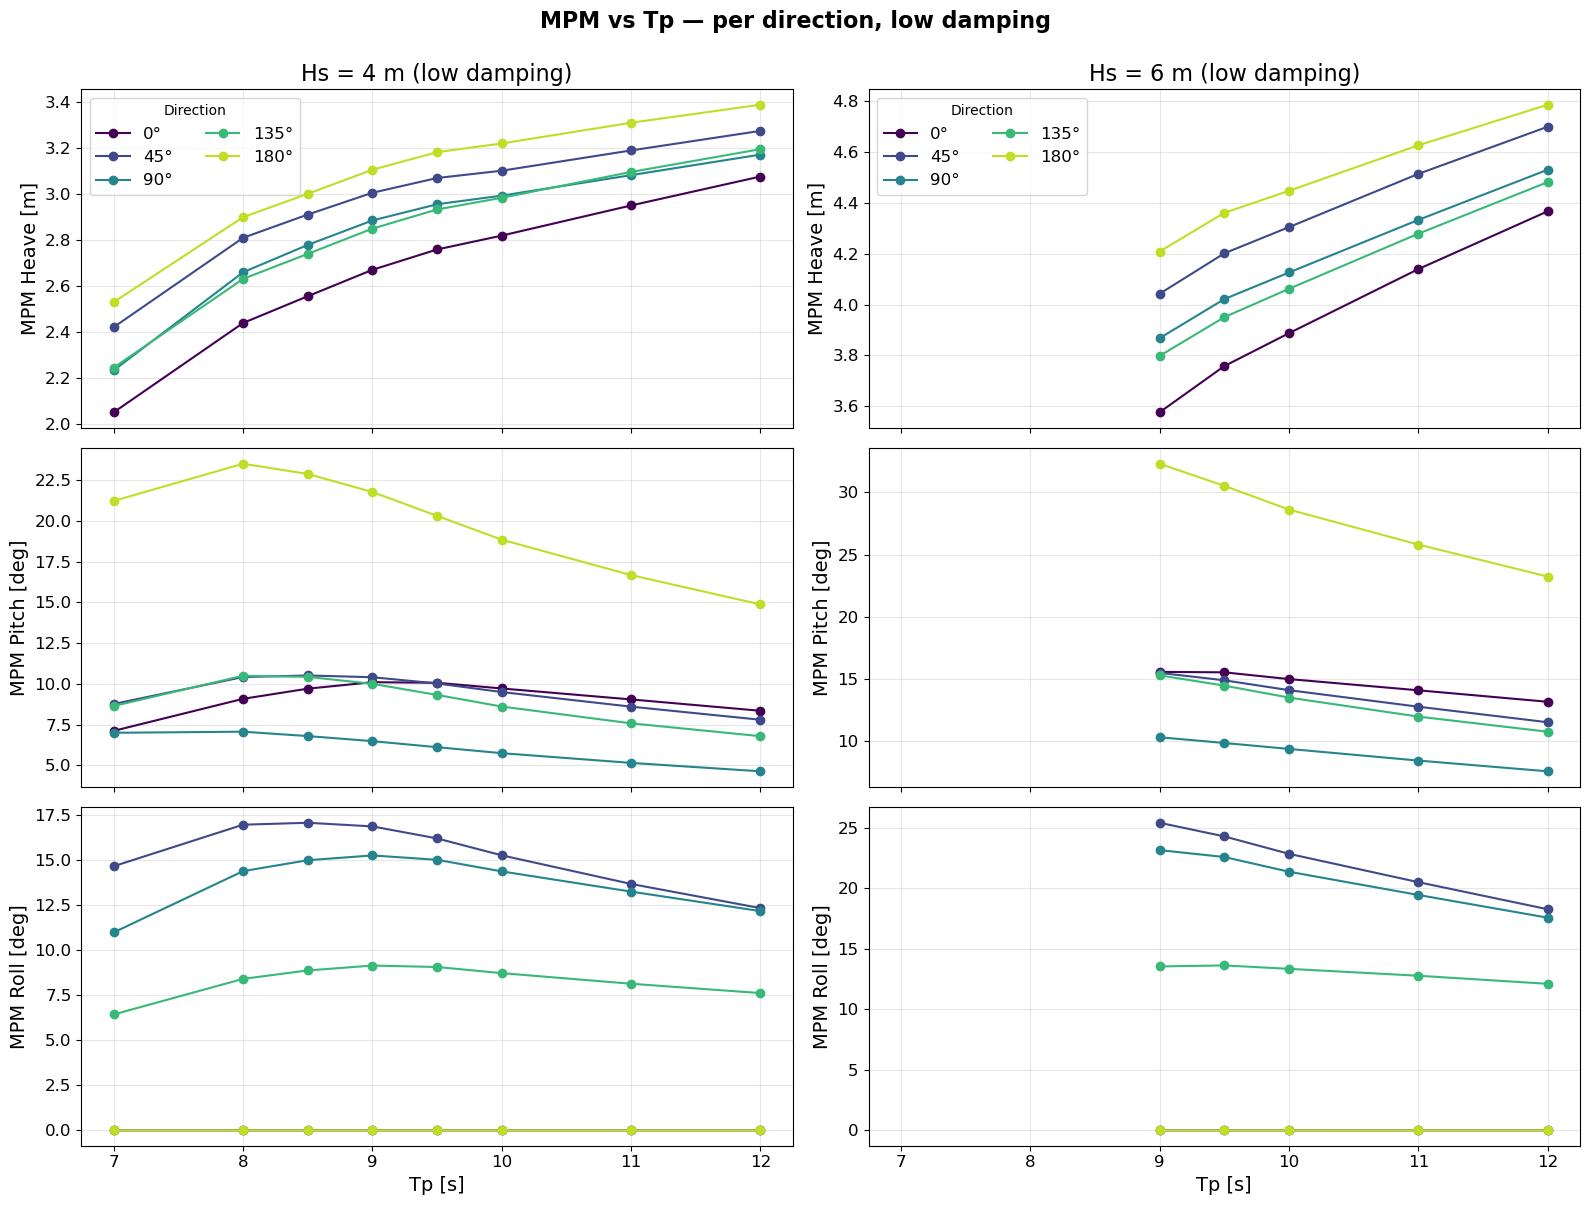

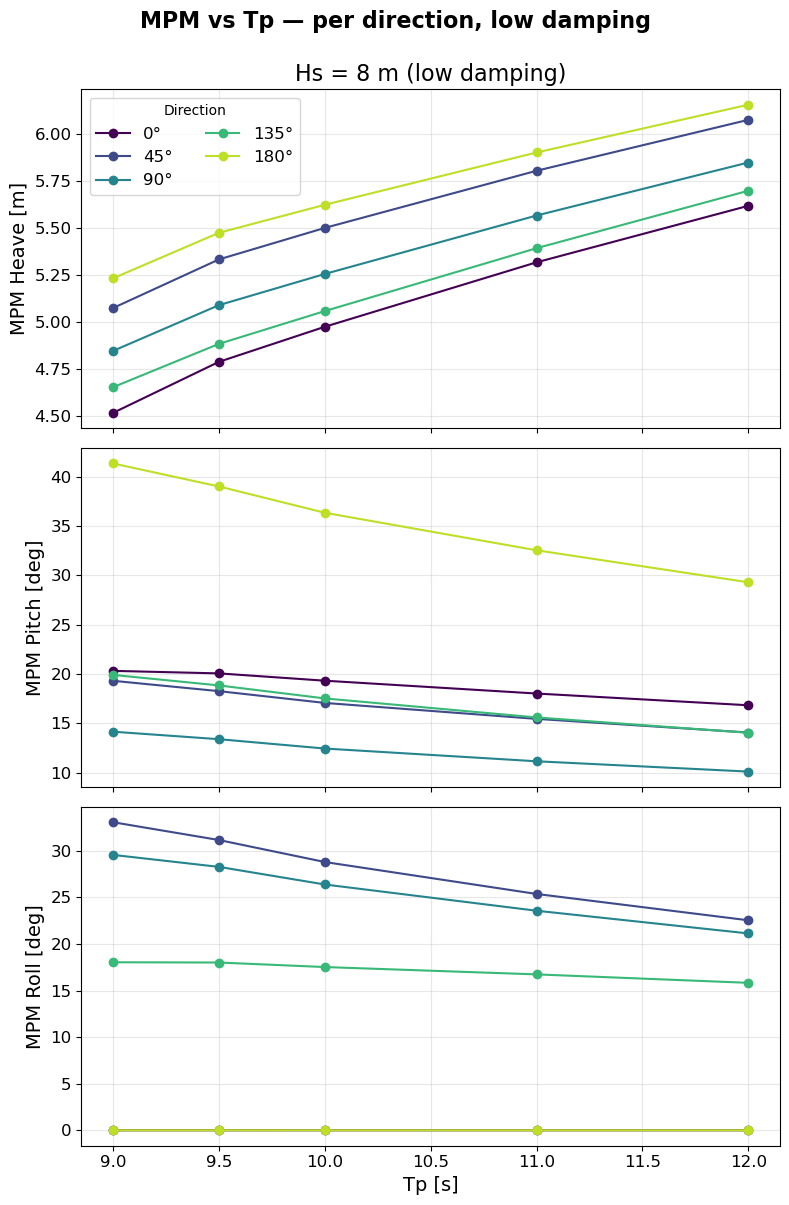

In [20]:
DIR_COLORS = plt.cm.viridis(np.linspace(0, 0.9, len(DIRECTIONS)))

for hs_pair in hs_pairs(HS_VALUES):
    ncols = len(hs_pair)
    fig, axes = plt.subplots(3, ncols, figsize=(8*ncols, 12), sharex=True, squeeze=False)

    for c, hs in enumerate(hs_pair):
        sub_hs = df[(df['Hs'] == hs) & (df['Damp_Heave'] == 'low')]
        for r, dof in enumerate(DOFS):
            mpm_c = f'MPM {dof["key"]} corr'
            ax = axes[r, c]

            for d, direction in enumerate(DIRECTIONS):
                sub_dir = sub_hs[sub_hs['Direction'] == direction].sort_values('Tp')
                if sub_dir.empty:
                    continue
                ax.plot(sub_dir['Tp'], sub_dir[mpm_c], 'o-',
                        label=f'{direction}°', color=DIR_COLORS[d])

            ax.set_ylabel(f'MPM {dof["name"]} [{dof["unit"]}]')
            ax.grid(True, alpha=0.3)
            if r == 0:
                ax.set_title(f'Hs = {hs} m (low damping)')
                ax.legend(title='Direction', ncol=2, loc = 'upper left')
            if r == 2:
                ax.set_xlabel('Tp [s]')

    fig.suptitle('MPM vs Tp — per direction, low damping', y=1.00, fontweight='bold')
    fig.tight_layout()
plt.show()

## 3. Effect of damping vs Hs — does quadratic grow with Hs?

For each Hs we compute the MPM reduction wrt the `low` baseline, averaged over Tp and direction:

$$\text{reduction} = \frac{\text{MPM}_\text{case} - \text{MPM}_\text{low}}{\text{MPM}_\text{low}} \times 100\%$$

If quadratic damping becomes more effective at higher Hs, the green line (quadhigh) should drop faster than the orange line (linhigh) as Hs increases.

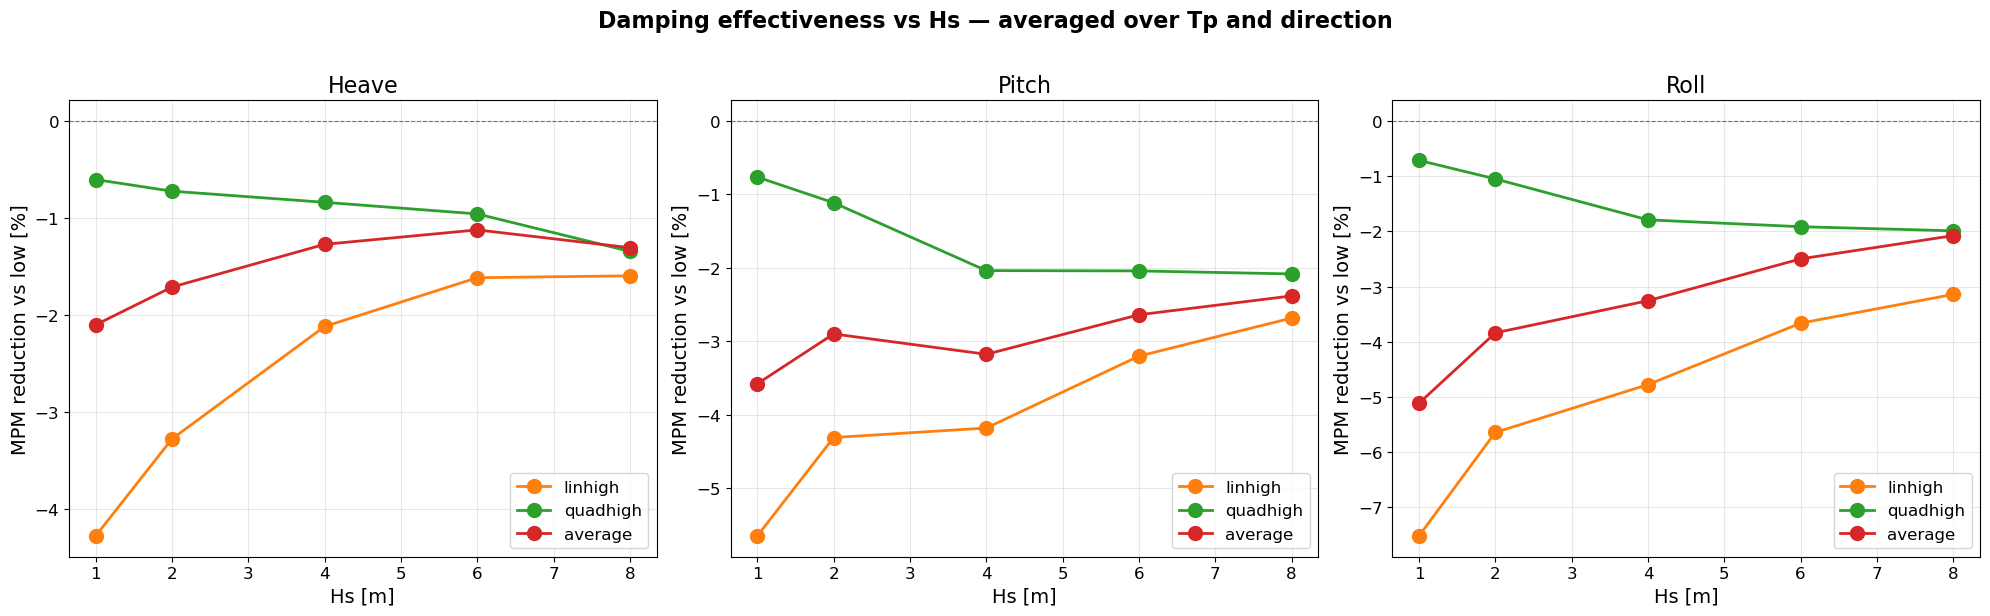

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, dof in zip(axes, DOFS):
    dcol = damping_col(dof['key'])
    mpm_c = f'MPM {dof["key"]} corr'

    # baseline: mean over Tp and direction per Hs, for the 'low' case
    base = df[df[dcol] == 'low'].groupby('Hs')[mpm_c].mean()

    for case in ['linhigh', 'quadhigh', 'average']:
        case_mpm = df[df[dcol] == case].groupby('Hs')[mpm_c].mean()
        common = case_mpm.index.intersection(base.index)
        pct = (case_mpm.loc[common] - base.loc[common]) / base.loc[common] * 100
        ax.plot(pct.index, pct.values, 'o-',
                label=case, color=DAMPING_COLORS[case], linewidth=2, markersize=10)

    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_title(f'{dof["name"]}')
    ax.set_xlabel('Hs [m]')
    ax.set_ylabel('MPM reduction vs low [%]')
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle('Damping effectiveness vs Hs — averaged over Tp and direction',
             y=1.02, fontweight='bold')
fig.tight_layout()
plt.show()

## 4. Effect of damping vs Tp — does quadratic grow with Tp?

Same idea, but now the % reduction is averaged over Hs and direction, plotted vs Tp.

If quadratic damping becomes more effective at higher Tp, the green line should drop faster as Tp increases.

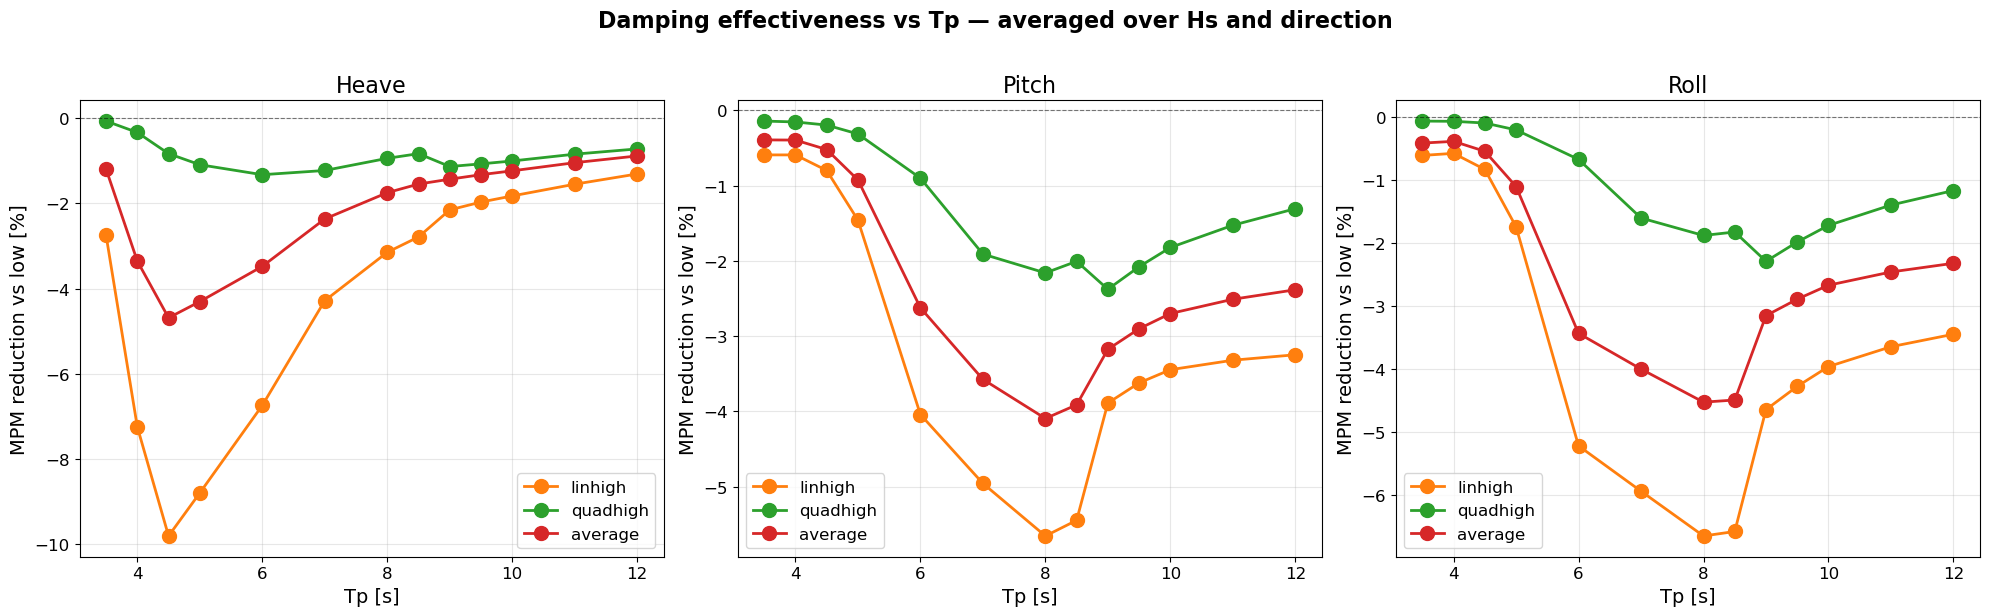

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, dof in zip(axes, DOFS):
    dcol = damping_col(dof['key'])
    mpm_c = f'MPM {dof["key"]} corr'

    base = df[df[dcol] == 'low'].groupby('Tp')[mpm_c].mean()

    for case in ['linhigh', 'quadhigh', 'average']:
        case_mpm = df[df[dcol] == case].groupby('Tp')[mpm_c].mean()
        common = case_mpm.index.intersection(base.index)
        pct = (case_mpm.loc[common] - base.loc[common]) / base.loc[common] * 100
        ax.plot(pct.index, pct.values, 'o-',
                label=case, color=DAMPING_COLORS[case], linewidth=2, markersize=10)

    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_title(f'{dof["name"]}')
    ax.set_xlabel('Tp [s]')
    ax.set_ylabel('MPM reduction vs low [%]')
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle('Damping effectiveness vs Tp — averaged over Hs and direction',
             y=1.02, fontweight='bold')
fig.tight_layout()
plt.show()

## 5. Direct quadratic-vs-linear comparison

Two panels per DOF: % MPM reduction vs `low`, plotted against Hs (left) and Tp (right). Only `linhigh` and `quadhigh` are shown, so the crossover is visible. The claim holds when `quadhigh` (green) drops below `linhigh` (orange) as Hs or Tp grows.

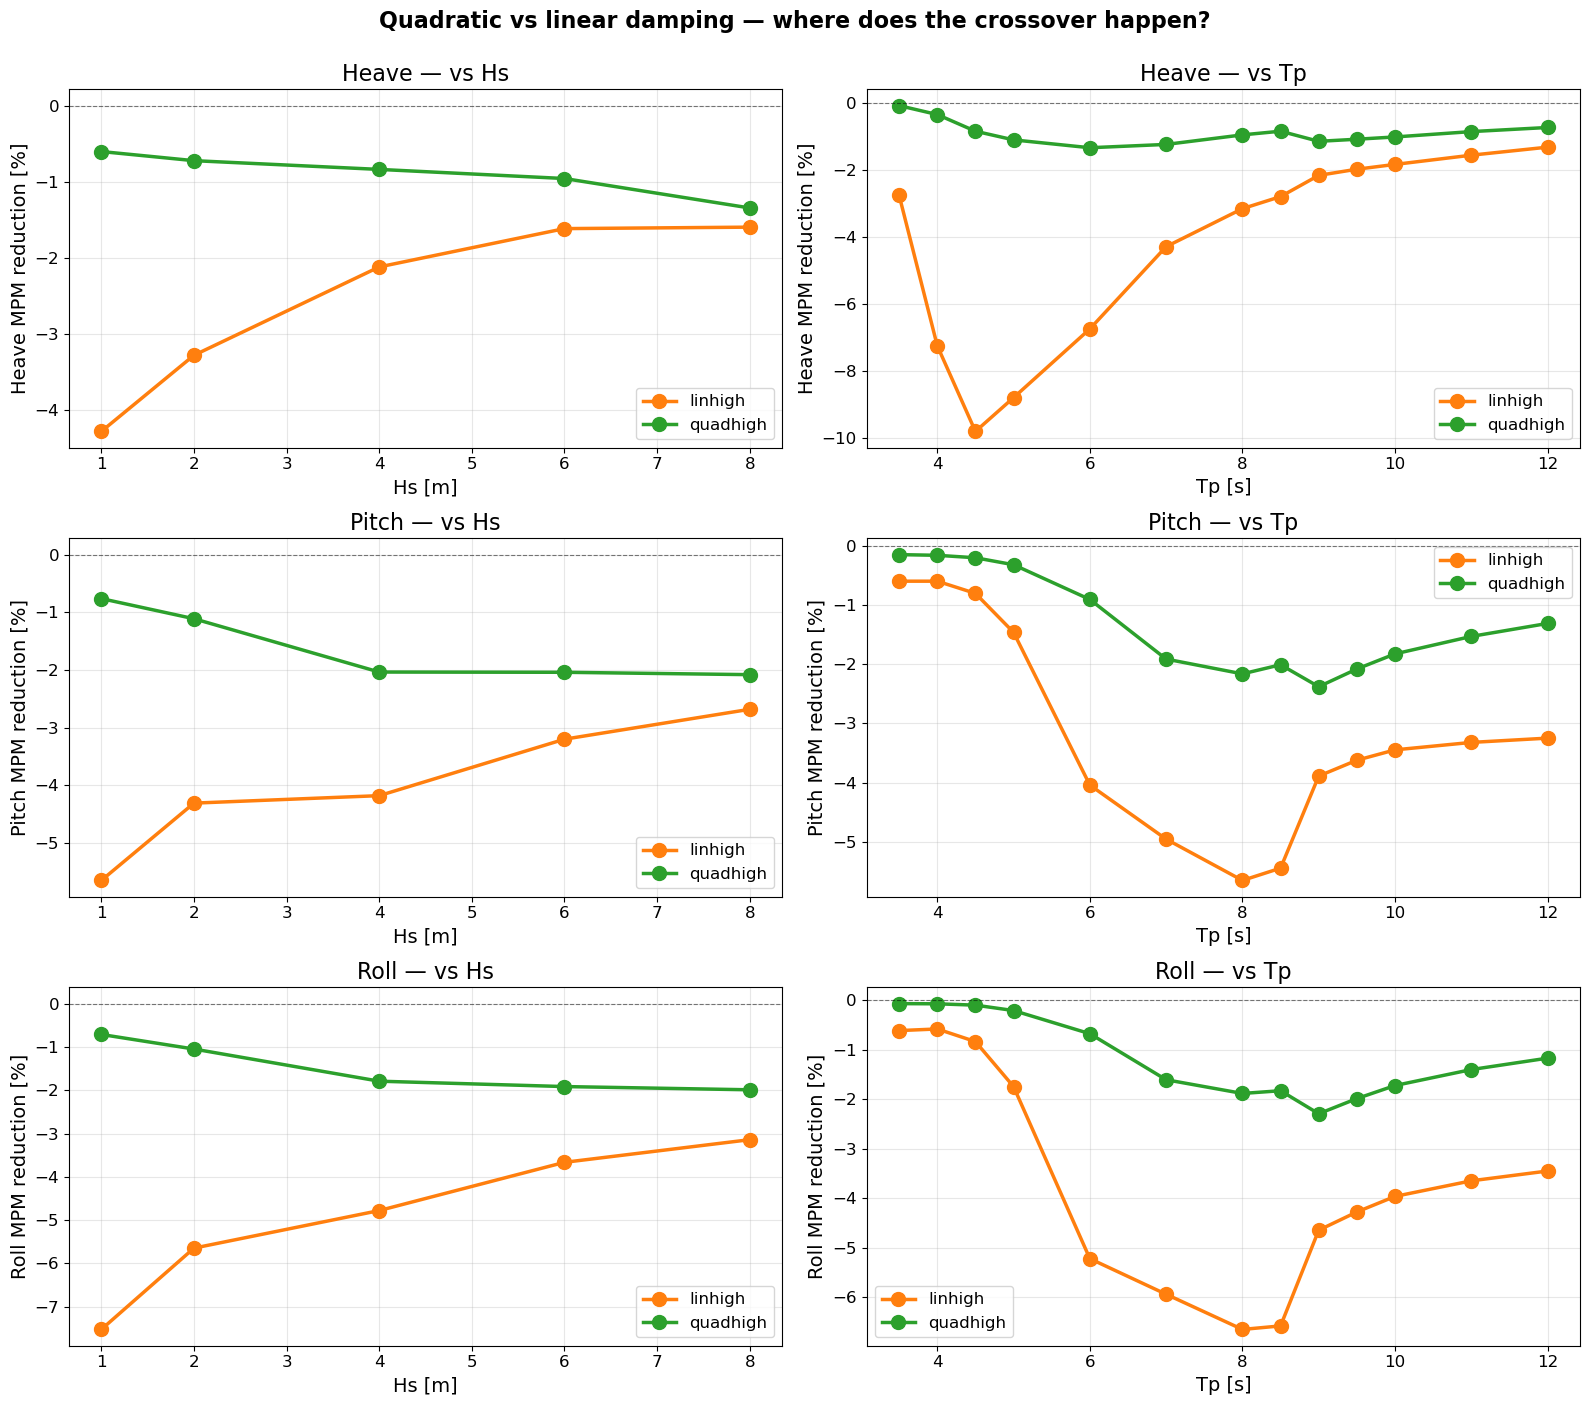

In [18]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

for r, dof in enumerate(DOFS):
    dcol = damping_col(dof['key'])
    mpm_c = f'MPM {dof["key"]} corr'

    # vs Hs
    ax = axes[r, 0]
    base = df[df[dcol] == 'low'].groupby('Hs')[mpm_c].mean()
    for case in ['linhigh', 'quadhigh']:
        case_mpm = df[df[dcol] == case].groupby('Hs')[mpm_c].mean()
        pct = (case_mpm - base) / base * 100
        ax.plot(pct.index, pct.values, 'o-',
                label=case, color=DAMPING_COLORS[case],
                linewidth=2.5, markersize=10)
    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_xlabel('Hs [m]')
    ax.set_ylabel(f'{dof["name"]} MPM reduction [%]')
    ax.set_title(f'{dof["name"]} — vs Hs')
    ax.grid(True, alpha=0.3)
    ax.legend()

    # vs Tp
    ax = axes[r, 1]
    base = df[df[dcol] == 'low'].groupby('Tp')[mpm_c].mean()
    for case in ['linhigh', 'quadhigh']:
        case_mpm = df[df[dcol] == case].groupby('Tp')[mpm_c].mean()
        pct = (case_mpm - base) / base * 100
        ax.plot(pct.index, pct.values, 'o-',
                label=case, color=DAMPING_COLORS[case],
                linewidth=2.5, markersize=10)
    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_xlabel('Tp [s]')
    ax.set_ylabel(f'{dof["name"]} MPM reduction [%]')
    ax.set_title(f'{dof["name"]} — vs Tp')
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle('Quadratic vs linear damping — where does the crossover happen?',
             y=1.00, fontweight='bold')
fig.tight_layout()
plt.show()

## 6. Why `average` damping doesn't cut it

For each (Hs, Tp) we compute the MPM with `average` damping and compare it to the **best** of `linhigh` and `quadhigh` at that same (Hs, Tp). If `average` were a good compromise, the points would lie close to zero. A consistent shortfall means the compromise loses meaningful performance.

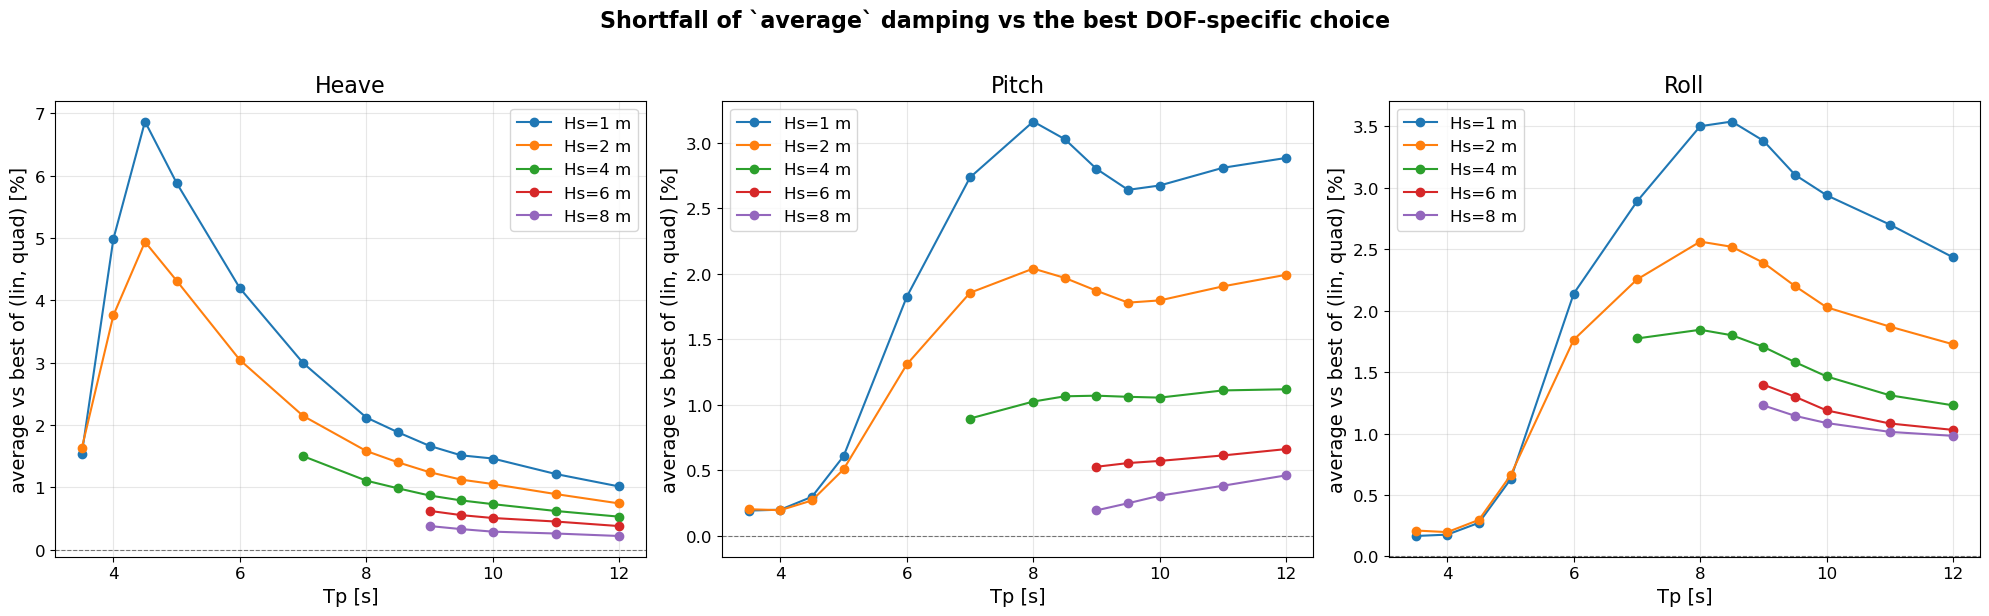

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, dof in zip(axes, DOFS):
    dcol = damping_col(dof['key'])
    mpm_c = f'MPM {dof["key"]} corr'

    pivot = df.groupby([dcol, 'Hs', 'Tp'])[mpm_c].mean().unstack(dcol)

    if 'average' not in pivot.columns:
        ax.set_title(f'{dof["name"]} — no average data')
        continue

    best_focused = pivot[['linhigh', 'quadhigh']].min(axis=1)
    avg = pivot['average']
    shortfall_pct = ((avg - best_focused) / best_focused * 100).rename('shortfall').reset_index()

    for hs in HS_VALUES:
        s = shortfall_pct[shortfall_pct['Hs'] == hs].sort_values('Tp')
        if s.empty:
            continue
        ax.plot(s['Tp'], s['shortfall'], 'o-', label=f'Hs={hs} m')

    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_xlabel('Tp [s]')
    ax.set_ylabel('average vs best of (lin, quad) [%]')
    ax.set_title(f'{dof["name"]}')
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle('Shortfall of `average` damping vs the best DOF-specific choice',
             y=1.02, fontweight='bold')
fig.tight_layout()
plt.show()